
Human Heights (Normal)
Mean: 170.19
Median: 170.25
👉 Left-Skewed


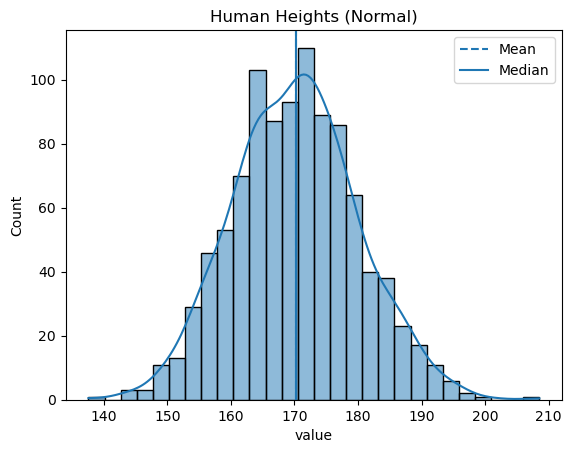


Household Incomes (Right-Skewed)
Mean: 50399.3
Median: 36296.56
👉 Right-Skewed


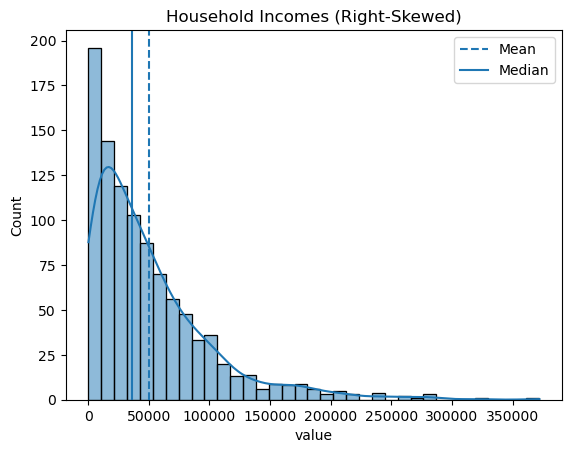


Easy Exam Scores (Left-Skewed)
Mean: 90.27
Median: 93.23
👉 Left-Skewed


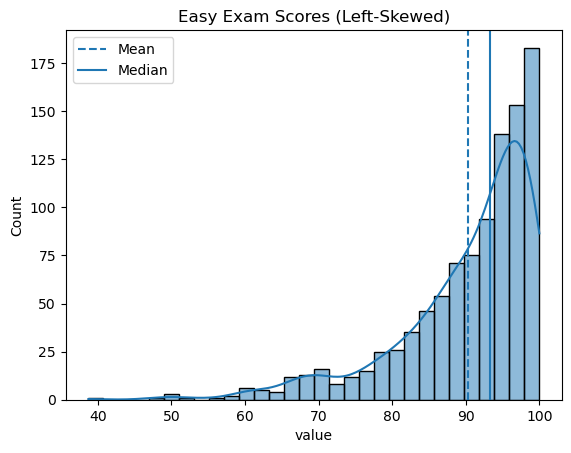

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
heights = pd.DataFrame({
    "value": np.random.normal(loc=170, scale=10, size=1000)
})
incomes = pd.DataFrame({
    "value": np.random.exponential(scale=50000, size=1000)
})
scores = pd.DataFrame({
    "value": 100 - np.random.exponential(scale=10, size=1000)
})
datasets = {
    "Human Heights (Normal)": heights,
    "Household Incomes (Right-Skewed)": incomes,
    "Easy Exam Scores (Left-Skewed)": scores
}
for name, df in datasets.items():

    mean_val = df["value"].mean()
    median_val = df["value"].median()

    print(f"\n{name}")
    print("Mean:", round(mean_val, 2))
    print("Median:", round(median_val, 2))

    if mean_val > median_val:
        print("👉 Right-Skewed")
    elif mean_val < median_val:
        print("👉 Left-Skewed")
    else:
        print("👉 Approximately Normal")

    plt.figure()
    sns.histplot(df["value"], kde=True)

    plt.axvline(mean_val, linestyle="--", label="Mean")
    plt.axvline(median_val, linestyle="-", label="Median")

    plt.title(name)
    plt.legend()
    plt.show()

In [2]:
import pandas as pd
import numpy as np

# Step 1: Generate a dataset (example: exam scores)
np.random.seed(42)
data = pd.DataFrame({
    "score": np.random.normal(loc=70, scale=10, size=100)
})

# Add some extreme values (outliers)
data.loc[98] = 120
data.loc[99] = 20

# Step 2: Calculate Mean (μ) and Standard Deviation (σ)
mu = data["score"].mean()
sigma = data["score"].std()

print("Mean (μ):", mu)
print("Standard Deviation (σ):", sigma)

# Step 3: Create z_score column
data["z_score"] = (data["score"] - mu) / sigma

# Step 4: Identify outliers where |Z| > 3
outliers = data[np.abs(data["z_score"]) > 3]

print("\nOutliers (|Z| > 3):")
print(outliers)

Mean (μ): 68.98448219373233
Standard Deviation (σ): 11.531436860255706

Outliers (|Z| > 3):
    score   z_score
98  120.0  4.424038
99   20.0 -4.247908


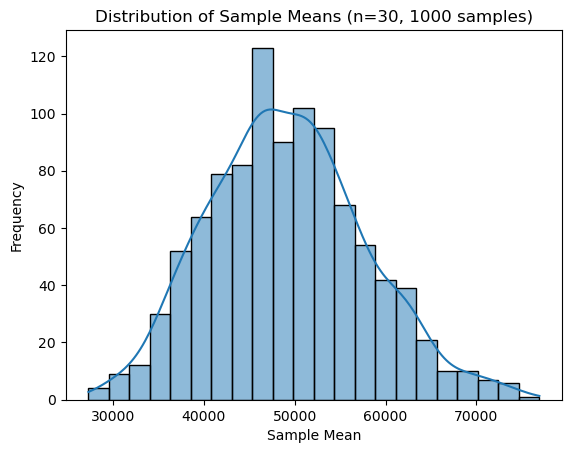

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
data = np.random.exponential(scale=50000, size=10000)
data = pd.Series(data)
sample_means = []
for _ in range(1000):
    sample = data.sample(n=30, replace=True)
    sample_means.append(sample.mean())
plt.figure()
sns.histplot(sample_means, kde=True)
plt.title("Distribution of Sample Means (n=30, 1000 samples)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

In [1]:
import sqlite3

# Connect to database (creates if doesn't exist)
conn = sqlite3.connect('internship.db')
cursor = conn.cursor()

# Create table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS interns (
        id INTEGER PRIMARY KEY,
        name TEXT,
        track TEXT,
        stipend REAL
    )
''')

# Insert sample data
sample_interns = [
    (1, 'Alice', 'Data Science', 20000),
    (2, 'Bob', 'Web Dev', 18000),
    (3, 'Charlie', 'Data Science', 21000),
    (4, 'Diana', 'Mobile Dev', 19000),
    (5, 'Eve', 'Web Dev', 18500)
]
cursor.executemany('INSERT OR IGNORE INTO interns VALUES (?, ?, ?, ?)', sample_interns)

# Query: Get name and track of all interns
cursor.execute('SELECT name, track FROM interns')
result = cursor.fetchall()
print("Interns:")
for row in result:
    print(row)

# Cleanup
conn.commit()
conn.close()

Interns:
('Alice', 'Data Science')
('Bob', 'Web Dev')
('Charlie', 'Data Science')
('Diana', 'Mobile Dev')
('Eve', 'Web Dev')


In [2]:
import sqlite3

conn = sqlite3.connect('internship.db')
cursor = conn.cursor()

# Filter: Data Science interns with stipend > 5000
cursor.execute('''
    SELECT name, stipend
    FROM interns
    WHERE track = 'Data Science' AND stipend > 5000
''')
print("Data Science interns with stipend > 5000:")
print(cursor.fetchall())

# Aggregate: Average stipend per track
cursor.execute('''
    SELECT track, AVG(stipend) AS avg_stipend
    FROM interns
    GROUP BY track
''')
print("\nAverage stipend by track:")
print(cursor.fetchall())

# Count: Interns per track
cursor.execute('''
    SELECT track, COUNT(*) AS intern_count
    FROM interns
    GROUP BY track
''')
print("\nIntern count by track:")
print(cursor.fetchall())

conn.close()

Data Science interns with stipend > 5000:
[('Alice', 20000.0), ('Charlie', 21000.0)]

Average stipend by track:
[('Data Science', 20500.0), ('Mobile Dev', 19000.0), ('Web Dev', 18250.0)]

Intern count by track:
[('Data Science', 2), ('Mobile Dev', 1), ('Web Dev', 2)]


In [3]:
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect('internship.db')
cursor = conn.cursor()

# Create mentors table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS mentors (
        mentor_id INTEGER PRIMARY KEY,
        mentor_name TEXT,
        track TEXT
    )
''')

# Insert sample mentors
mentors = [
    (1, 'Dr. Smith', 'Data Science'),
    (2, 'Ms. Lee', 'Web Dev'),
    (3, 'Mr. Patel', 'Mobile Dev')
]
cursor.executemany('INSERT OR IGNORE INTO mentors VALUES (?, ?, ?)', mentors)

# JOIN query: interns with their track's mentor
query = '''
    SELECT i.name, i.track, m.mentor_name
    FROM interns i
    INNER JOIN mentors m ON i.track = m.track
'''
df = pd.read_sql_query(query, conn)

print(df)

# Cleanup
conn.commit()
conn.close()

      name         track mentor_name
0    Alice  Data Science   Dr. Smith
1      Bob       Web Dev     Ms. Lee
2  Charlie  Data Science   Dr. Smith
3    Diana    Mobile Dev   Mr. Patel
4      Eve       Web Dev     Ms. Lee
